# Home Credit Default Risk — Phase 2: Per-file EDA

**Objective:** Deep exploratory analysis on every file — distributions, outliers, categorical frequencies, and bivariate analysis vs TARGET.

1. Numeric column distributions (main file)
2. Categorical column frequencies (main file)
3. Bivariate analysis — each feature vs TARGET
4. Correlation heatmap
5. DAYS columns (time-based) analysis
6. Outlier detection
7. Secondary file EDA (bureau, previous_application, installments, POS, CC)
8. EDA Summary & feature shortlist

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

plt.rcParams.update({
    'figure.facecolor'  : '#FAFAFA',
    'axes.facecolor'    : '#FAFAFA',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
})
C0       = '#534AB7'   # default=0 color
C1       = '#D85A30'   # default=1 color
PALETTE  = [C0, C1]

DATA_DIR = '../data'   # <-- update if needed

FILES = {
    'application_train'     : 'application_train.csv',
    'bureau'                : 'bureau.csv',
    'bureau_balance'        : 'bureau_balance.csv',
    'previous_application'  : 'previous_application.csv',
    'POS_CASH_balance'      : 'POS_CASH_balance.csv',
    'installments_payments' : 'installments_payments.csv',
    'credit_card_balance'   : 'credit_card_balance.csv',
}

dfs = {}
for name, fname in FILES.items():
    path = os.path.join(DATA_DIR, fname)
    if os.path.exists(path):
        dfs[name] = pd.read_csv(path)
        print(f'  ✓ {fname:<40} {dfs[name].shape}')

train = dfs['application_train'].copy()
print(f'\nMain training set: {train.shape[0]:,} rows × {train.shape[1]} columns')

  ✓ application_train.csv                    (307511, 122)
  ✓ bureau.csv                               (1716428, 17)
  ✓ bureau_balance.csv                       (27299925, 3)
  ✓ previous_application.csv                 (1670214, 37)
  ✓ POS_CASH_balance.csv                     (10001358, 8)
  ✓ installments_payments.csv                (13605401, 8)
  ✓ credit_card_balance.csv                  (3840312, 23)

Main training set: 307,511 rows × 122 columns


## Numeric Column Distributions — application_train

We plot histograms with KDE for all numeric columns.
- Skewed distributions → will need `log1p` transform in Phase 3

In [2]:
# ── Identify numeric cols (exclude IDs and TARGET) ────────────────────────────
ID_COLS     = ['SK_ID_CURR', 'SK_ID_BUREAU', 'SK_ID_PREV']
num_cols    = [c for c in train.select_dtypes(include='number').columns
               if c not in ID_COLS + ['TARGET']]

print(f'Numeric columns to plot: {len(num_cols)}')

# ── Compute skewness for each ─────────────────────────────────────────────────
skew_df = pd.DataFrame({
    'Column'   : num_cols,
    'Skewness' : [train[c].skew() for c in num_cols],
    'Null %'   : [train[c].isnull().mean()*100 for c in num_cols],
}).sort_values('Skewness', key=abs, ascending=False)

high_skew = skew_df[skew_df['Skewness'].abs() > 1]
print(f'Highly skewed columns (|skew| > 1): {len(high_skew)}')
display(high_skew.head(20))

Numeric columns to plot: 104
Highly skewed columns (|skew| > 1): 86


,Column,Skewness,Null %
11,FLAG_MOBIL,-554.5367,0.0000
88,FLAG_DOCUMENT_12,392.1148,0.0000
1,AMT_INCOME_TOTAL,391.5597,0.0000
86,FLAG_DOCUMENT_10,209.5891,0.0000
78,FLAG_DOCUMENT_2,153.7918,0.0000
102,AMT_REQ_CREDIT_BUREAU_QRT,134.3658,13.5016
80,FLAG_DOCUMENT_4,110.8944,0.0000
83,FLAG_DOCUMENT_7,72.1741,0.0000
93,FLAG_DOCUMENT_17,61.2141,0.0000
97,FLAG_DOCUMENT_21,54.6129,0.0000


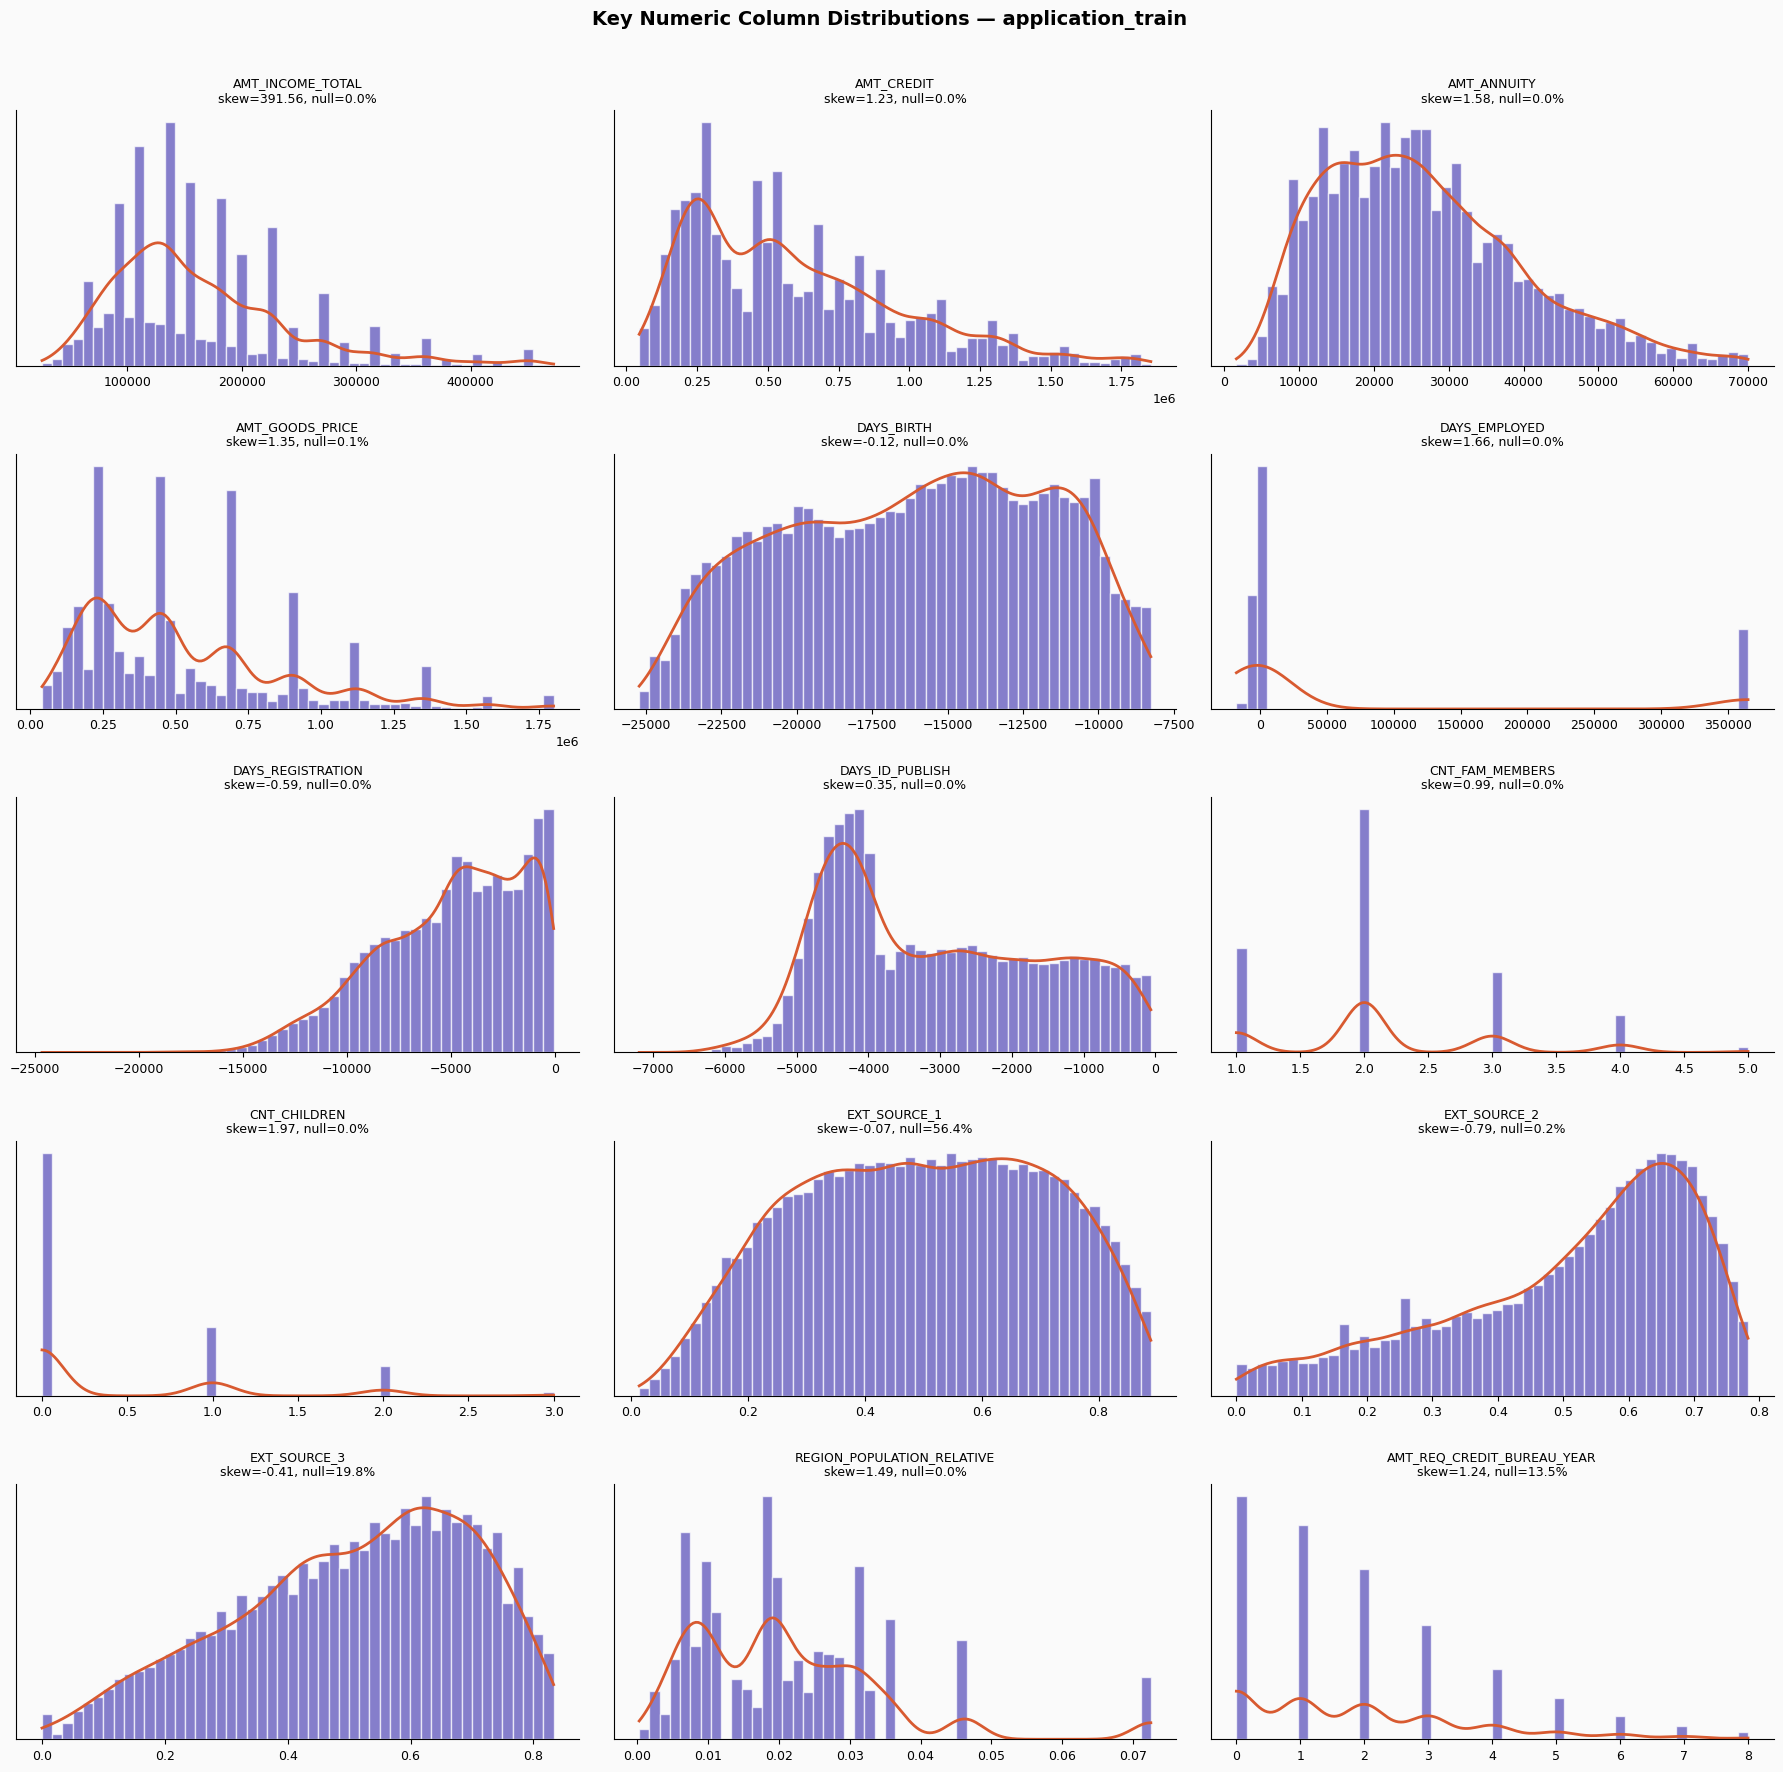

Columns with high skew → will apply log1p transform in Phase 3: AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY


In [3]:
# ── Plot distributions for top numeric columns (by importance/interest) ────────
# Handpicked key financial columns for focused EDA
KEY_NUM_COLS = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
    'CNT_FAM_MEMBERS', 'CNT_CHILDREN', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'REGION_POPULATION_RELATIVE', 'AMT_REQ_CREDIT_BUREAU_YEAR',
]
KEY_NUM_COLS = [c for c in KEY_NUM_COLS if c in train.columns]

ncols = 3
nrows = int(np.ceil(len(KEY_NUM_COLS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
fig.suptitle('Key Numeric Column Distributions — application_train', fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, col in enumerate(KEY_NUM_COLS):
    ax = axes[i]
    data = train[col].dropna()
    # Cap extreme values for readability
    q99 = data.quantile(0.99)
    data_plot = data[data <= q99]

    ax.hist(data_plot, bins=50, color=C0, alpha=0.7, edgecolor='white', density=True)
    try:
        kde_x = np.linspace(data_plot.min(), data_plot.max(), 200)
        kde   = stats.gaussian_kde(data_plot.sample(min(5000, len(data_plot)), random_state=42))
        ax.plot(kde_x, kde(kde_x), color=C1, lw=2)
    except Exception:
        pass

    skew_val = data.skew()
    ax.set_title(f'{col}\nskew={skew_val:.2f}, null={train[col].isnull().mean()*100:.1f}%',
                 fontsize=9)
    ax.set_yticks([])

# Hide unused subplots
for j in range(len(KEY_NUM_COLS), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('phase2_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Columns with high skew → will apply log1p transform in Phase 3: AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY')

## Categorical Column Frequencies — application_train

For each categorical column we plot value frequencies.
High cardinality categoricals (>20 unique values) need target encoding or frequency encoding in Phase 3.

In [4]:
cat_cols = [c for c in train.select_dtypes('object').columns if c not in ID_COLS]
print(f'Categorical columns: {len(cat_cols)}')
for c in cat_cols:
    print(f'  {c:<40} unique={train[c].nunique():>3}  null={train[c].isnull().mean()*100:.1f}%')

Categorical columns: 16
  NAME_CONTRACT_TYPE                       unique=  2  null=0.0%
  CODE_GENDER                              unique=  3  null=0.0%
  FLAG_OWN_CAR                             unique=  2  null=0.0%
  FLAG_OWN_REALTY                          unique=  2  null=0.0%
  NAME_TYPE_SUITE                          unique=  7  null=0.4%
  NAME_INCOME_TYPE                         unique=  8  null=0.0%
  NAME_EDUCATION_TYPE                      unique=  5  null=0.0%
  NAME_FAMILY_STATUS                       unique=  6  null=0.0%
  NAME_HOUSING_TYPE                        unique=  6  null=0.0%
  OCCUPATION_TYPE                          unique= 18  null=31.3%
  WEEKDAY_APPR_PROCESS_START               unique=  7  null=0.0%
  ORGANIZATION_TYPE                        unique= 58  null=0.0%
  FONDKAPREMONT_MODE                       unique=  4  null=68.4%
  HOUSETYPE_MODE                           unique=  3  null=50.2%
  WALLSMATERIAL_MODE                       unique=  7  null=50.

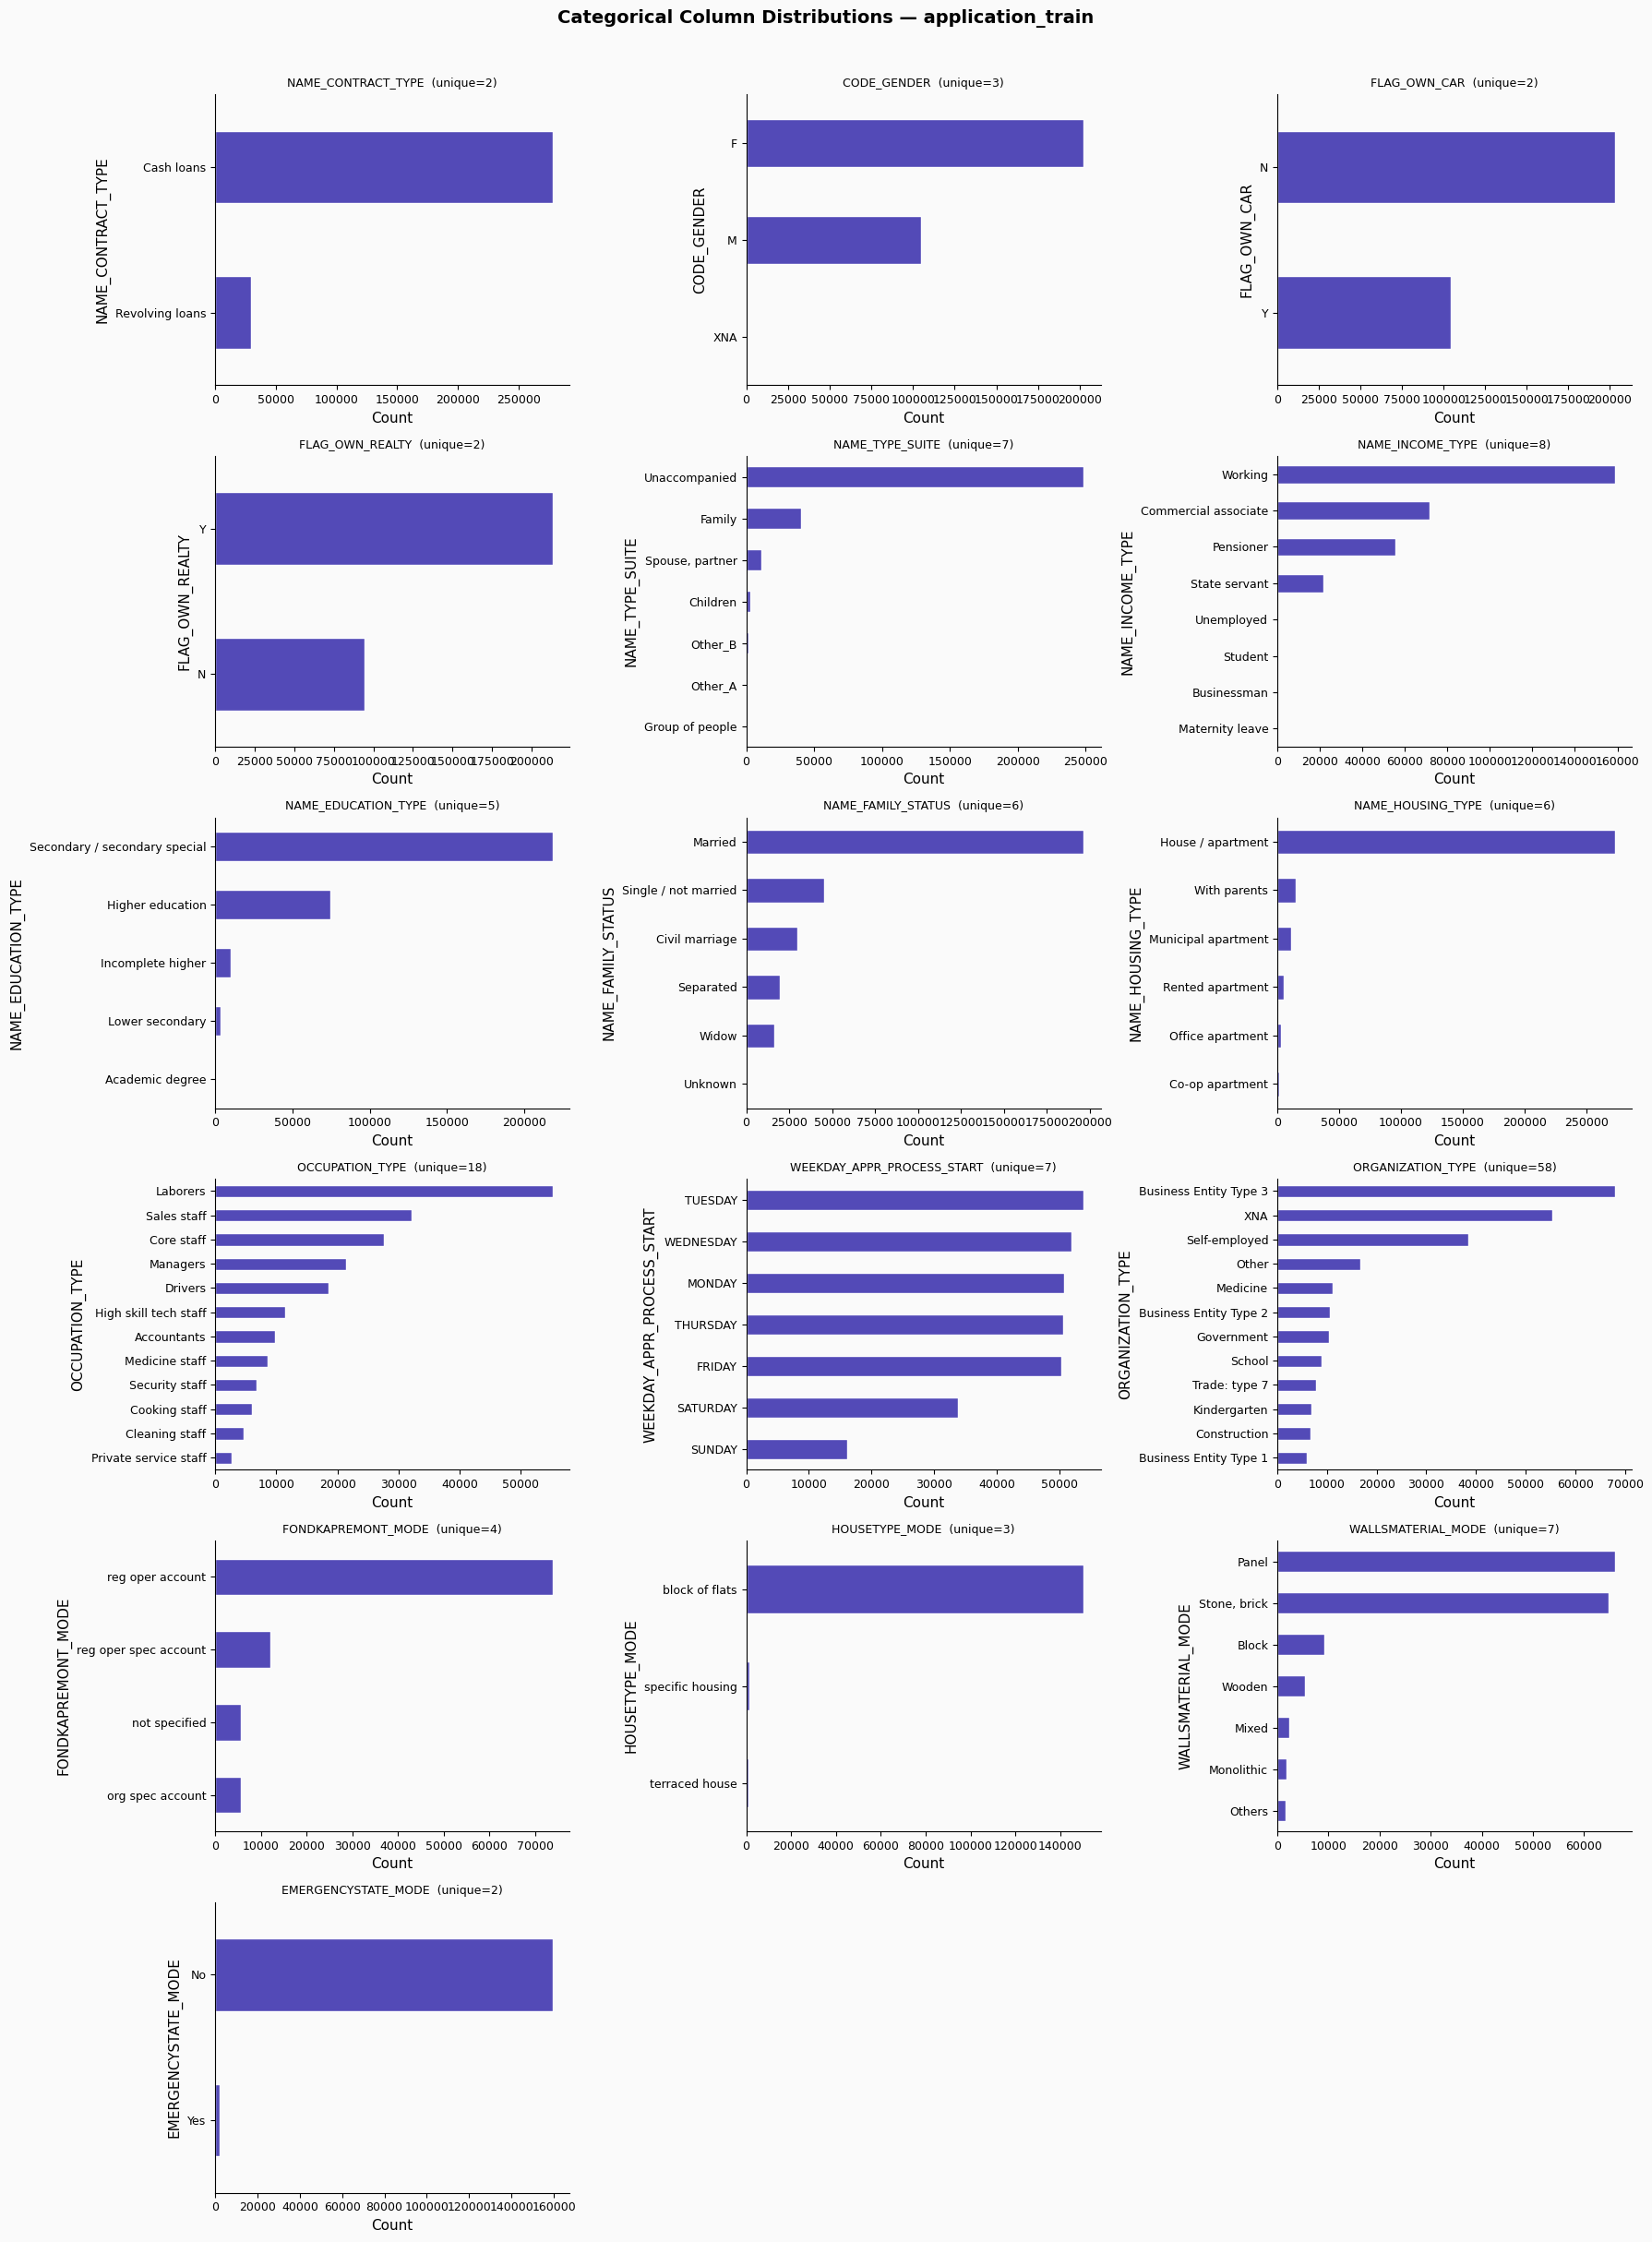

In [5]:
ncols = 3
nrows = int(np.ceil(len(cat_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
fig.suptitle('Categorical Column Distributions — application_train', fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    vc = train[col].value_counts().head(12)   # Top 12 categories
    vc.plot(kind='barh', ax=ax, color=C0, edgecolor='white')
    ax.set_title(f'{col}  (unique={train[col].nunique()})', fontsize=9)
    ax.set_xlabel('Count')
    ax.invert_yaxis()

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('phase2_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Bivariate Analysis — Features vs TARGET

This is the most important EDA section. We compare the distribution of each feature **split by TARGET**:
- For numeric features: overlapping KDE plots (default vs no-default)
- For categorical features: stacked bar showing default rate per category

Features with **high separation** between classes are strong predictors.

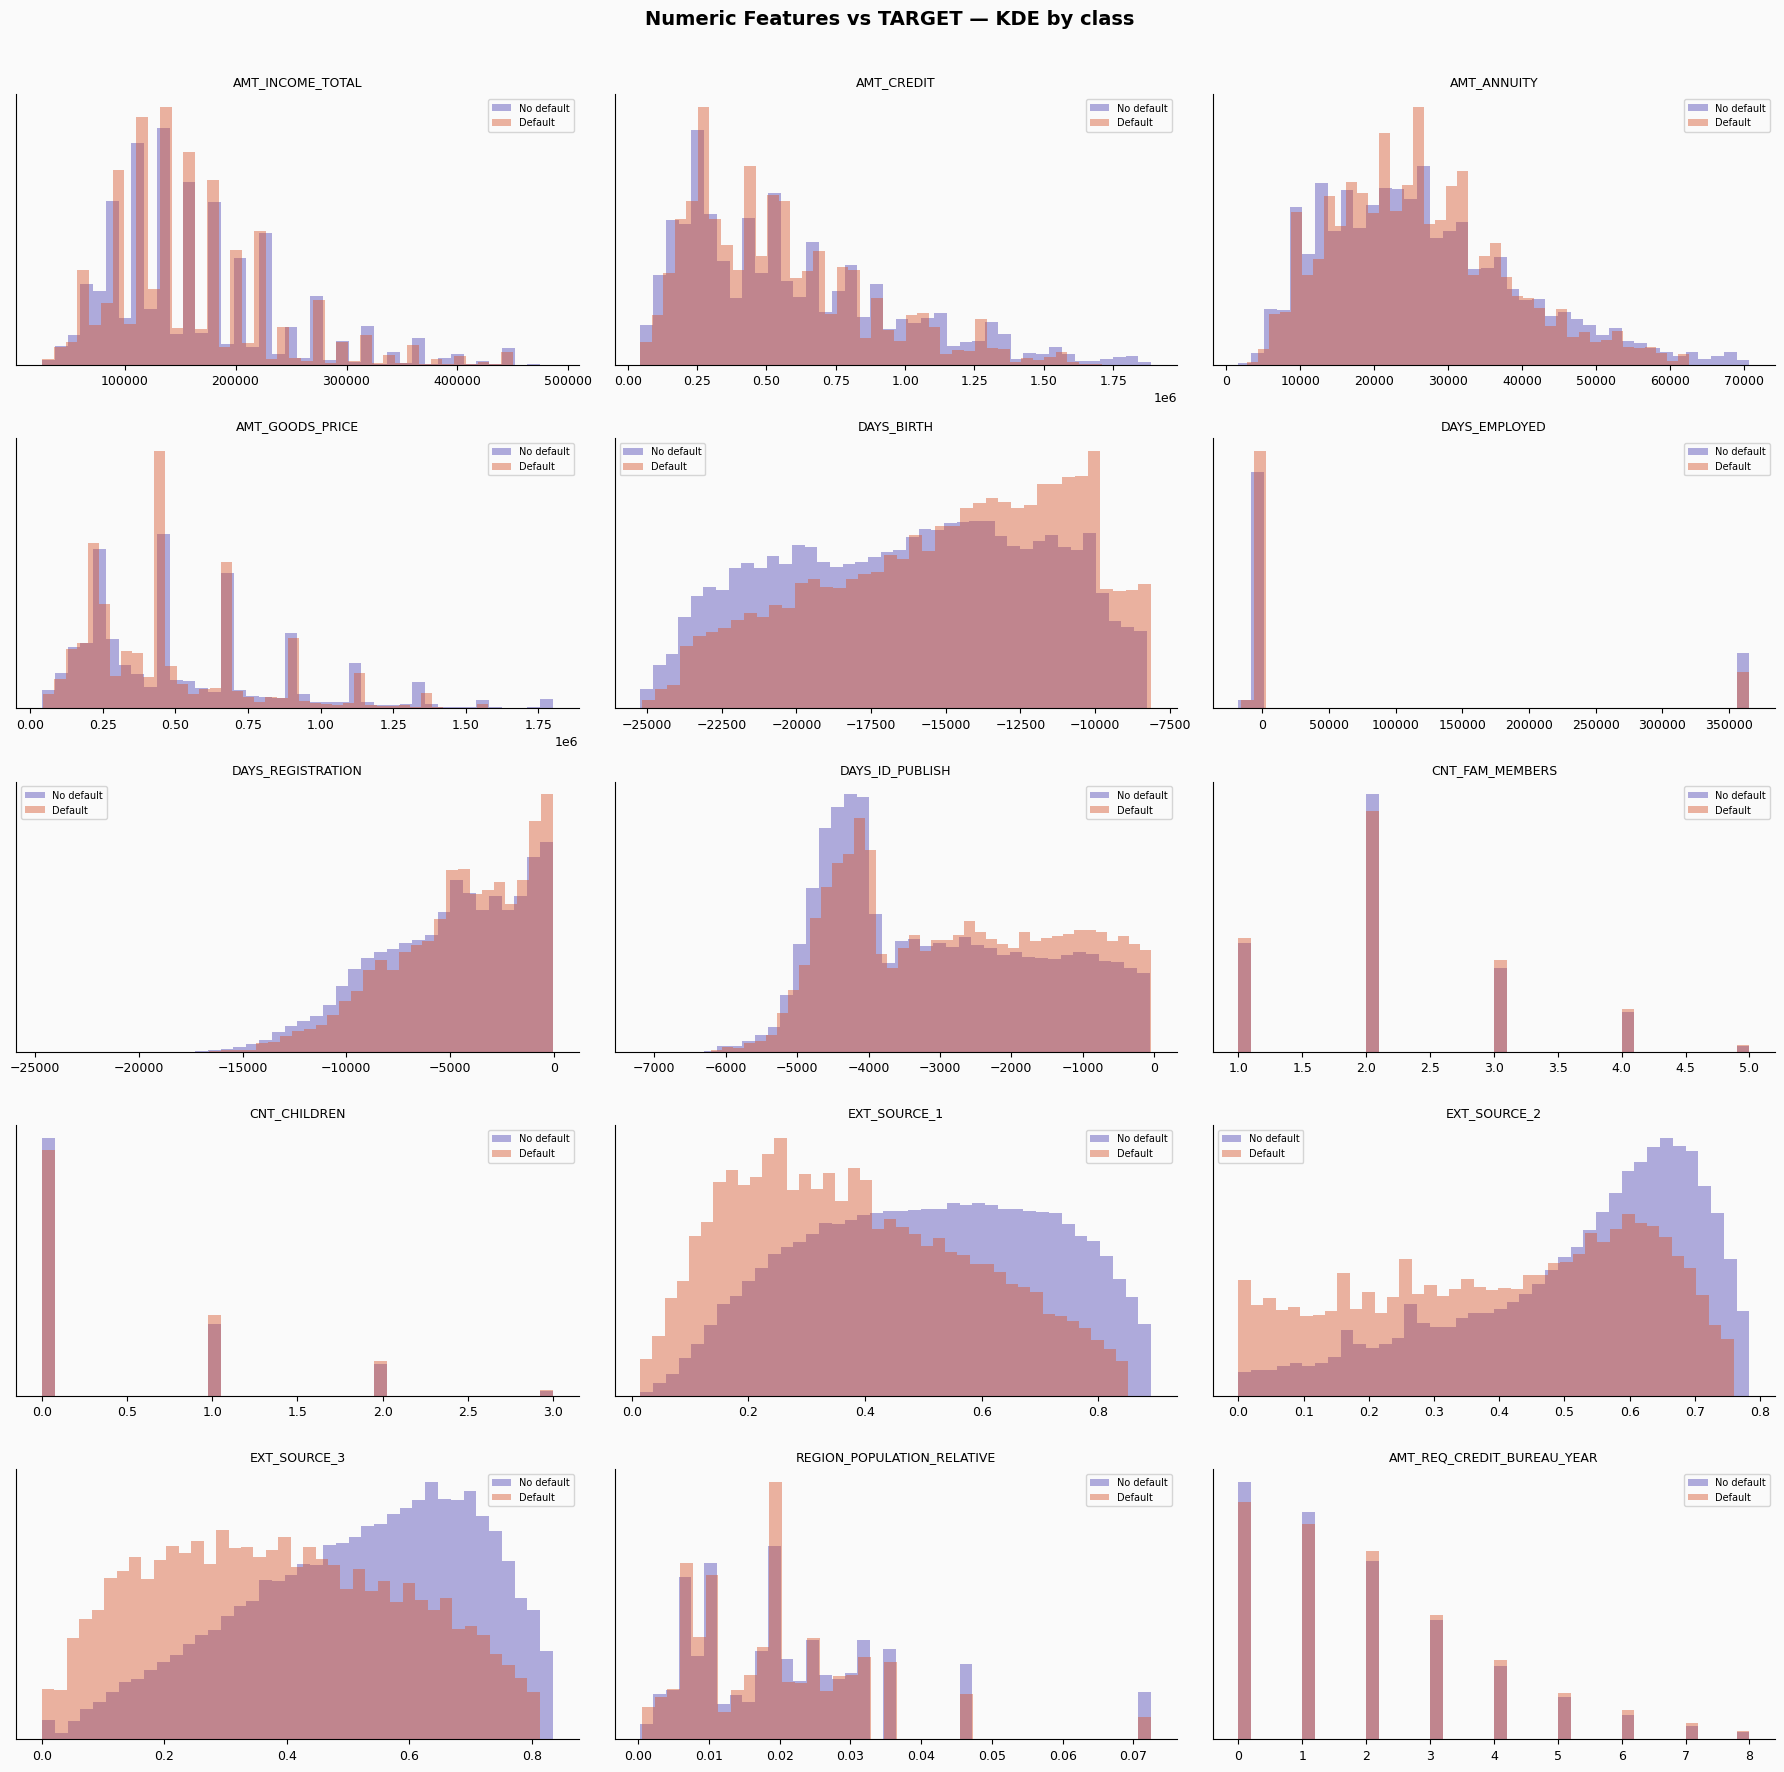

In [6]:
def plot_numeric_vs_target(df, col, ax):
    """Overlapping KDE of a numeric column split by TARGET."""
    for tgt, color, label in [(0, C0, 'No default'), (1, C1, 'Default')]:
        data = df.loc[df['TARGET'] == tgt, col].dropna()
        q99  = data.quantile(0.99)
        data = data[data <= q99]
        if len(data) > 10:
            ax.hist(data, bins=40, density=True, alpha=0.45,
                    color=color, label=label, edgecolor='none')
    ax.set_title(col, fontsize=9)
    ax.set_yticks([])
    ax.legend(fontsize=7)


def plot_cat_vs_target(df, col, ax):
    """Bar chart: default rate per category."""
    rates = df.groupby(col)['TARGET'].mean().sort_values(ascending=False).head(12)
    bars  = ax.barh(rates.index.astype(str), rates.values * 100,
                    color=[C1 if v > df['TARGET'].mean() else C0 for v in rates.values],
                    edgecolor='white')
    ax.axvline(df['TARGET'].mean() * 100, color='black', linestyle='--',
               lw=1, label=f'Overall avg ({df["TARGET"].mean()*100:.1f}%)')
    ax.set_xlabel('Default Rate %')
    ax.set_title(f'{col} — default rate per category', fontsize=9)
    ax.legend(fontsize=7)
    ax.invert_yaxis()


# ── Plot numeric key cols vs TARGET ──────────────────────────────────────────
ncols = 3
nrows = int(np.ceil(len(KEY_NUM_COLS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
fig.suptitle('Numeric Features vs TARGET — KDE by class', fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, col in enumerate(KEY_NUM_COLS):
    plot_numeric_vs_target(train, col, axes[i])

for j in range(len(KEY_NUM_COLS), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('phase2_bivariate_numeric.png', dpi=150, bbox_inches='tight')
plt.show()

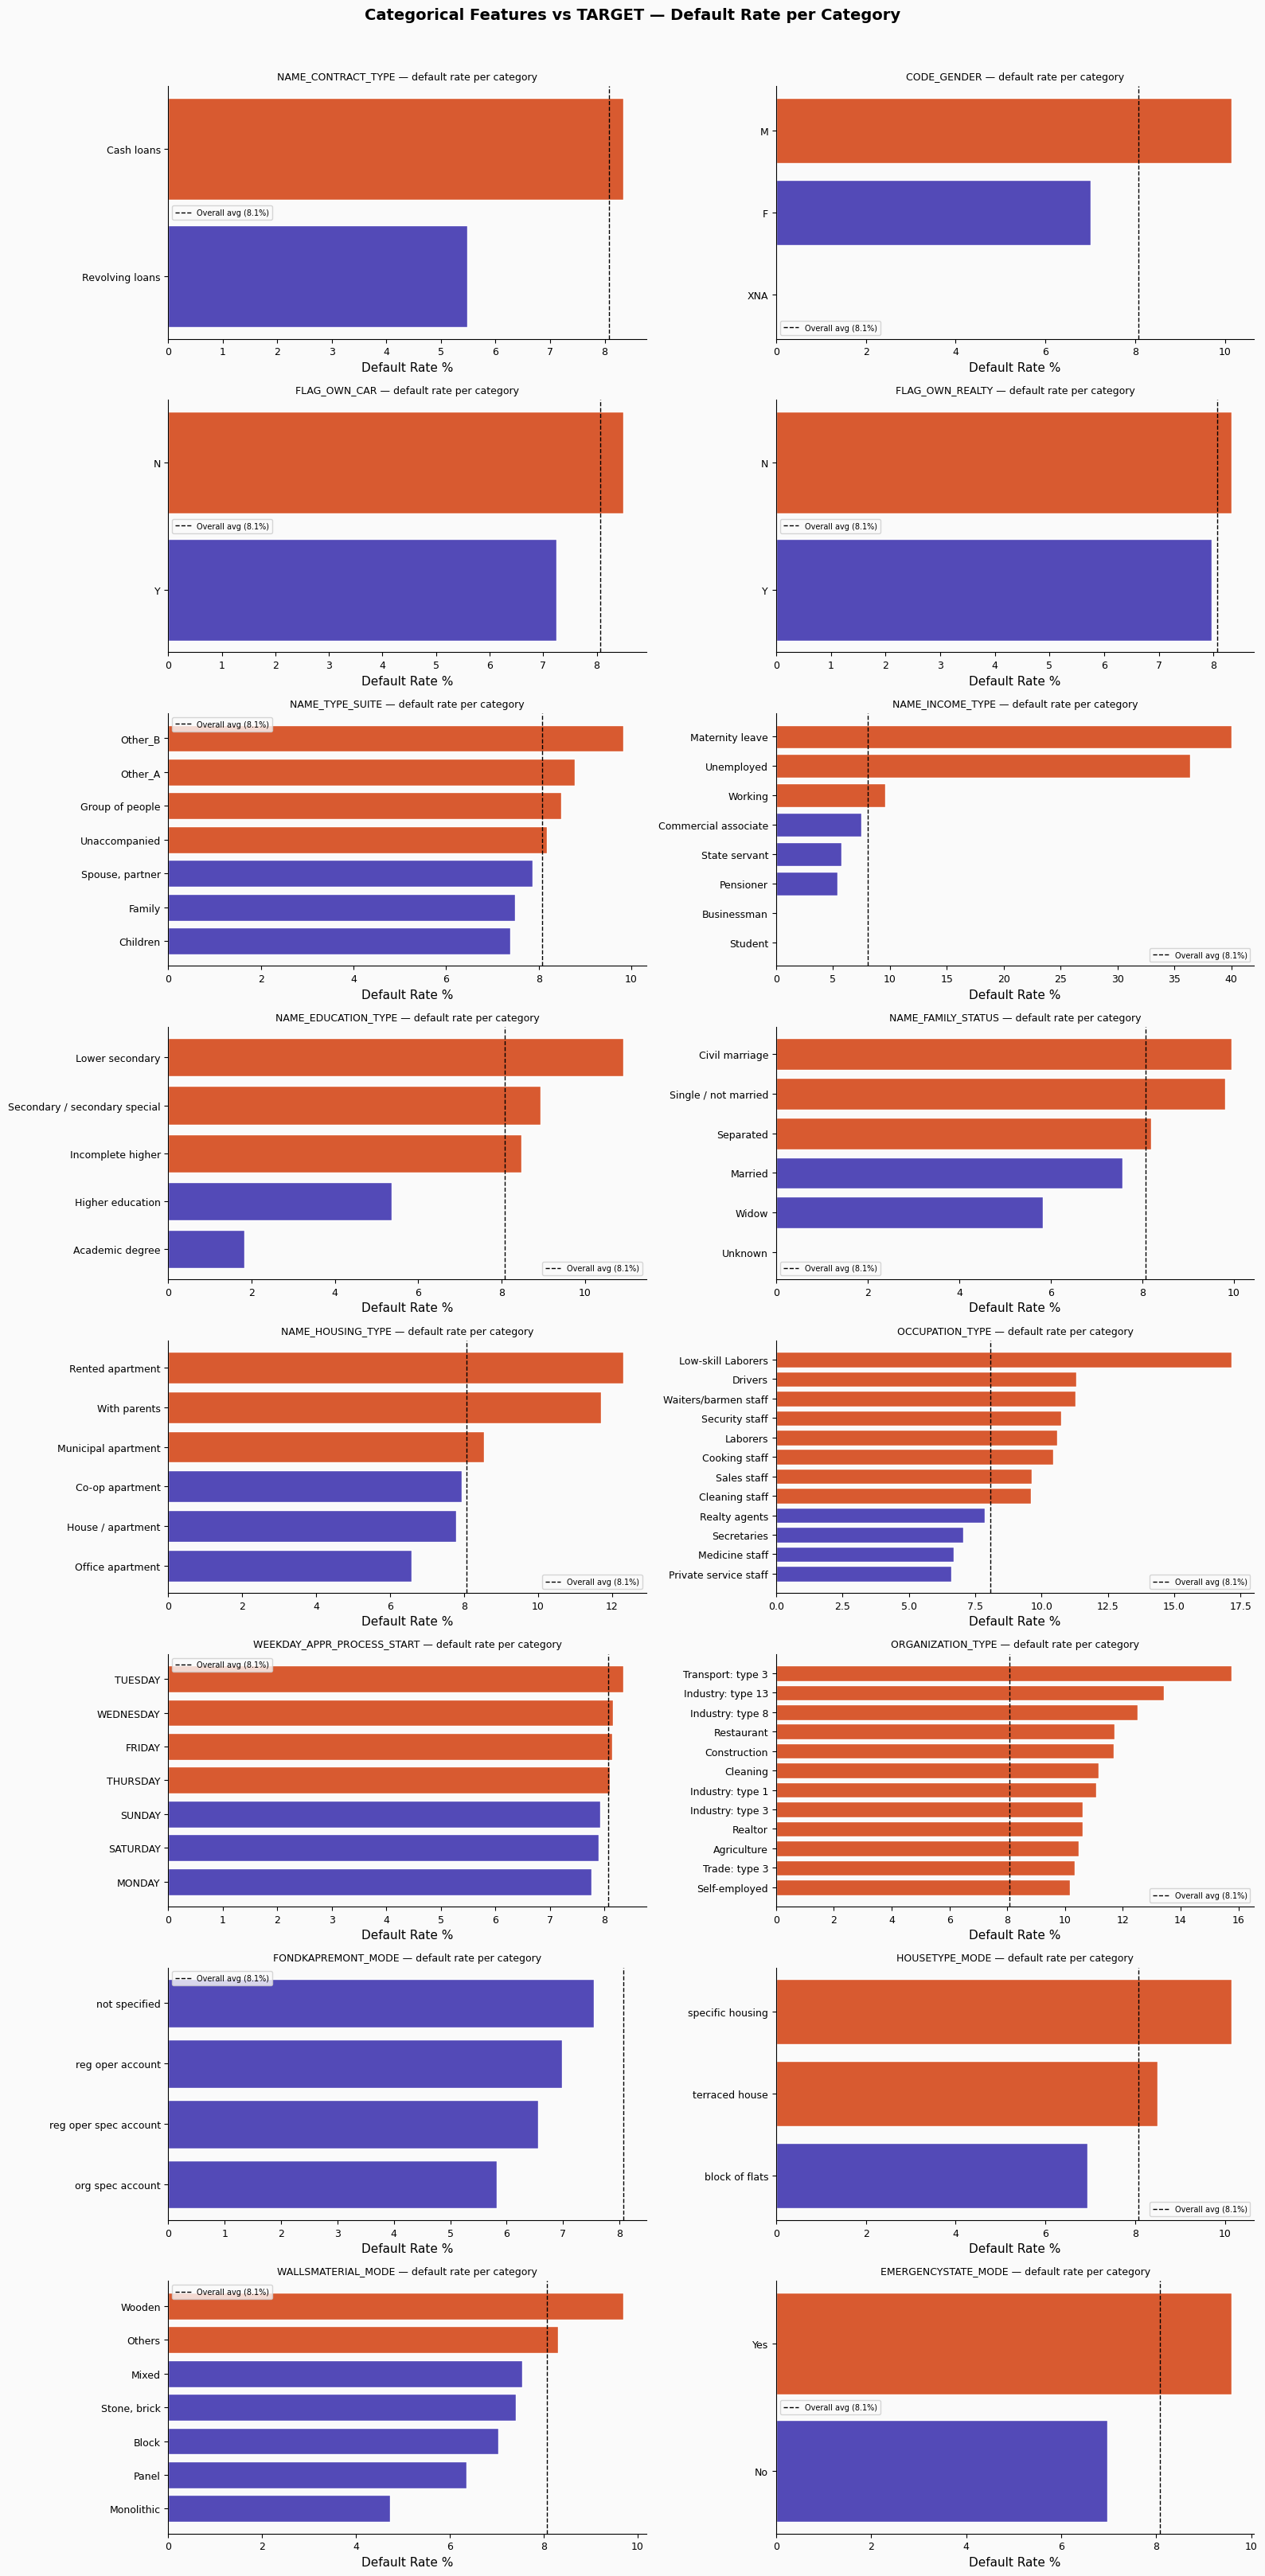

In [7]:
# ── Plot categorical cols vs TARGET ──────────────────────────────────────────
ncols = 2
nrows = int(np.ceil(len(cat_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
fig.suptitle('Categorical Features vs TARGET — Default Rate per Category',
             fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    plot_cat_vs_target(train, col, axes[i])

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('phase2_bivariate_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

## EXT_SOURCE Features — Deep Dive

`EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3` are external credit scores from third-party agencies.
They are consistently the **top 3 predictors** in this competition. Understand them carefully.

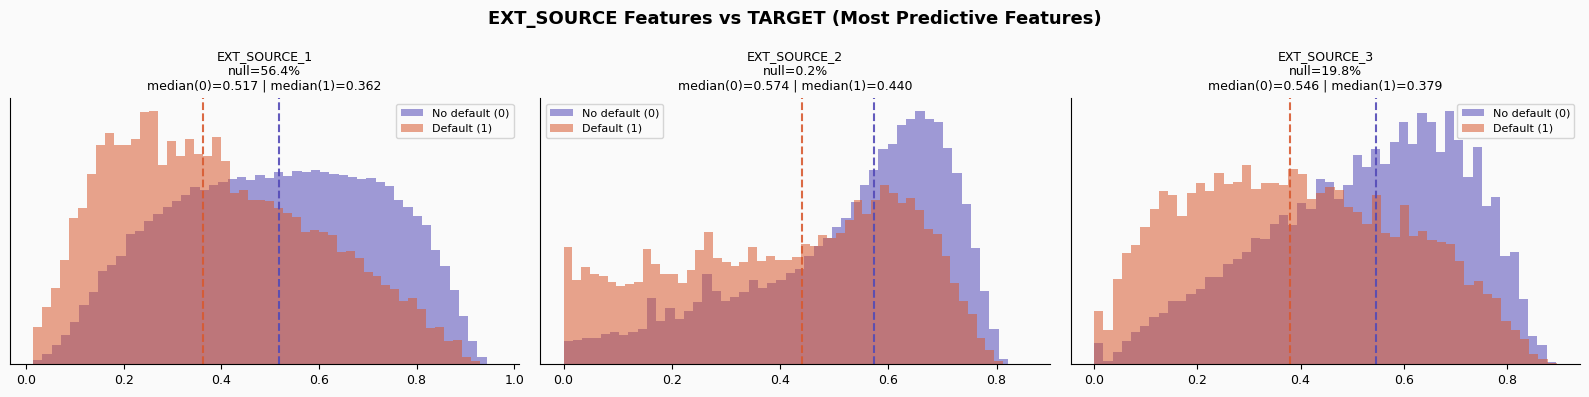

→ Higher EXT_SOURCE = lower default risk. Clear separation between classes.
→ Will create EXT_SOURCE_mean, EXT_SOURCE_min, EXT_SOURCE_product features in Phase 4.


In [8]:
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
ext_cols = [c for c in ext_cols if c in train.columns]

fig, axes = plt.subplots(1, len(ext_cols), figsize=(16, 4))
fig.suptitle('EXT_SOURCE Features vs TARGET (Most Predictive Features)',
             fontsize=13, fontweight='bold')

for i, col in enumerate(ext_cols):
    ax = axes[i]
    for tgt, color, label in [(0, C0, 'No default (0)'), (1, C1, 'Default (1)')]:
        data = train.loc[train['TARGET'] == tgt, col].dropna()
        ax.hist(data, bins=50, density=True, alpha=0.55,
                color=color, label=label, edgecolor='none')
    median_0 = train.loc[train['TARGET']==0, col].median()
    median_1 = train.loc[train['TARGET']==1, col].median()
    ax.axvline(median_0, color=C0, lw=1.5, linestyle='--', alpha=0.9)
    ax.axvline(median_1, color=C1, lw=1.5, linestyle='--', alpha=0.9)
    ax.set_title(f'{col}\nnull={train[col].isnull().mean()*100:.1f}%\n'
                 f'median(0)={median_0:.3f} | median(1)={median_1:.3f}', fontsize=9)
    ax.set_yticks([])
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('phase2_ext_source.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Higher EXT_SOURCE = lower default risk. Clear separation between classes.')
print('→ Will create EXT_SOURCE_mean, EXT_SOURCE_min, EXT_SOURCE_product features in Phase 4.')

## DAYS Columns Analysis

DAYS columns are stored as **negative integers** (days relative to loan application date).
- `DAYS_BIRTH` → age of client (negative days from birth to application)
- `DAYS_EMPLOYED` → days employed. Value **365243** = NOT EMPLOYED (anomaly marker, must be handled!)
- `DAYS_REGISTRATION`, `DAYS_ID_PUBLISH` → document-related

In [9]:
days_cols = [c for c in train.columns if 'DAYS' in c and c not in ID_COLS]
print('DAYS columns:', days_cols)
print()

for col in days_cols:
    anomaly_365243 = (train[col] == 365243).sum()
    print(f'{col:<30} min={train[col].min():>10,.0f}  max={train[col].max():>10,.0f}'
          f'  anomaly(365243)={anomaly_365243:,}')

print()
print('→ DAYS_EMPLOYED anomaly: 365243 rows represent unemployed clients.')
print('   Strategy: Replace 365243 with NaN, create binary flag DAYS_EMPLOYED_ANOM.')
print()
print('→ DAYS_BIRTH is negative. Convert to age in years: AGE_YEARS = -DAYS_BIRTH / 365')

DAYS columns: ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']

DAYS_BIRTH                     min=   -25,229  max=    -7,489  anomaly(365243)=0
DAYS_EMPLOYED                  min=   -17,912  max=   365,243  anomaly(365243)=55,374
DAYS_REGISTRATION              min=   -24,672  max=         0  anomaly(365243)=0
DAYS_ID_PUBLISH                min=    -7,197  max=         0  anomaly(365243)=0
DAYS_LAST_PHONE_CHANGE         min=    -4,292  max=         0  anomaly(365243)=0

→ DAYS_EMPLOYED anomaly: 365243 rows represent unemployed clients.
   Strategy: Replace 365243 with NaN, create binary flag DAYS_EMPLOYED_ANOM.

→ DAYS_BIRTH is negative. Convert to age in years: AGE_YEARS = -DAYS_BIRTH / 365


Default rate — Normal employed   : 8.66%
Default rate — Anomaly (365243)  : 5.40%
Default rate — Overall           : 8.07%
→ The anomaly flag itself carries predictive signal! Keep it as a feature.


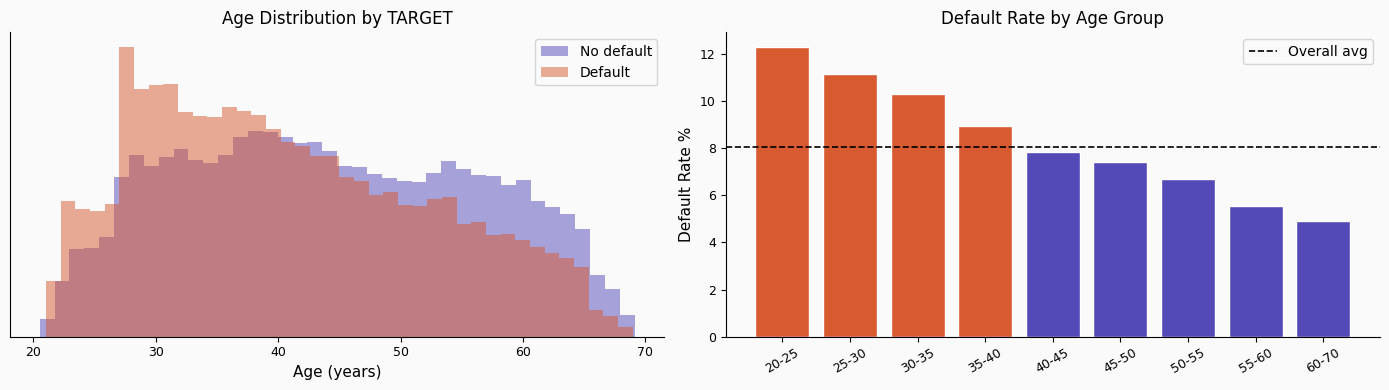

→ Younger clients (20-30) have higher default rates.


In [10]:
# ── DAYS_EMPLOYED anomaly impact on default rate ──────────────────────────────
if 'DAYS_EMPLOYED' in train.columns:
    train['DAYS_EMPLOYED_ANOM'] = (train['DAYS_EMPLOYED'] == 365243).astype(int)
    anom_rate   = train.loc[train['DAYS_EMPLOYED_ANOM']==1, 'TARGET'].mean()
    normal_rate = train.loc[train['DAYS_EMPLOYED_ANOM']==0, 'TARGET'].mean()
    overall     = train['TARGET'].mean()

    print(f'Default rate — Normal employed   : {normal_rate*100:.2f}%')
    print(f'Default rate — Anomaly (365243)  : {anom_rate*100:.2f}%')
    print(f'Default rate — Overall           : {overall*100:.2f}%')
    print('→ The anomaly flag itself carries predictive signal! Keep it as a feature.')

    # Age distribution by default
    train['AGE_YEARS'] = -train['DAYS_BIRTH'] / 365

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for tgt, color, label in [(0, C0, 'No default'), (1, C1, 'Default')]:
        axes[0].hist(train.loc[train['TARGET']==tgt, 'AGE_YEARS'].dropna(),
                     bins=40, density=True, alpha=0.5, color=color, label=label)
    axes[0].set_title('Age Distribution by TARGET')
    axes[0].set_xlabel('Age (years)')
    axes[0].legend()
    axes[0].set_yticks([])

    # Default rate by age group
    train['AGE_GROUP'] = pd.cut(train['AGE_YEARS'],
                                 bins=[20, 25, 30, 35, 40, 45, 50, 55, 60, 70],
                                 labels=['20-25','25-30','30-35','35-40',
                                         '40-45','45-50','50-55','55-60','60-70'])
    age_default = train.groupby('AGE_GROUP', observed=True)['TARGET'].mean() * 100
    axes[1].bar(age_default.index.astype(str), age_default.values,
                color=[C1 if v > overall*100 else C0 for v in age_default.values],
                edgecolor='white')
    axes[1].axhline(overall*100, color='black', linestyle='--', lw=1.2, label='Overall avg')
    axes[1].set_title('Default Rate by Age Group')
    axes[1].set_ylabel('Default Rate %')
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('phase2_days_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('→ Younger clients (20-30) have higher default rates.')

## Correlation Heatmap — Numeric Features

Identifies:
- Highly correlated feature pairs (>0.9) → candidates for dropping one
- Features most correlated with TARGET

Top 20 features by absolute correlation with TARGET:
EXT_SOURCE_3                  -0.1789
EXT_SOURCE_2                  -0.1605
EXT_SOURCE_1                  -0.1553
AGE_YEARS                     -0.0782
DAYS_BIRTH                     0.0782
REGION_RATING_CLIENT_W_CITY    0.0609
REGION_RATING_CLIENT           0.0589
DAYS_LAST_PHONE_CHANGE         0.0552
DAYS_ID_PUBLISH                0.0515
REG_CITY_NOT_WORK_CITY         0.0510
DAYS_EMPLOYED_ANOM            -0.0460
FLAG_EMP_PHONE                 0.0460
DAYS_EMPLOYED                 -0.0449
REG_CITY_NOT_LIVE_CITY         0.0444
FLAG_DOCUMENT_3                0.0443
FLOORSMAX_AVG                 -0.0440
FLOORSMAX_MEDI                -0.0438
FLOORSMAX_MODE                -0.0432
DAYS_REGISTRATION              0.0420
AMT_GOODS_PRICE               -0.0396


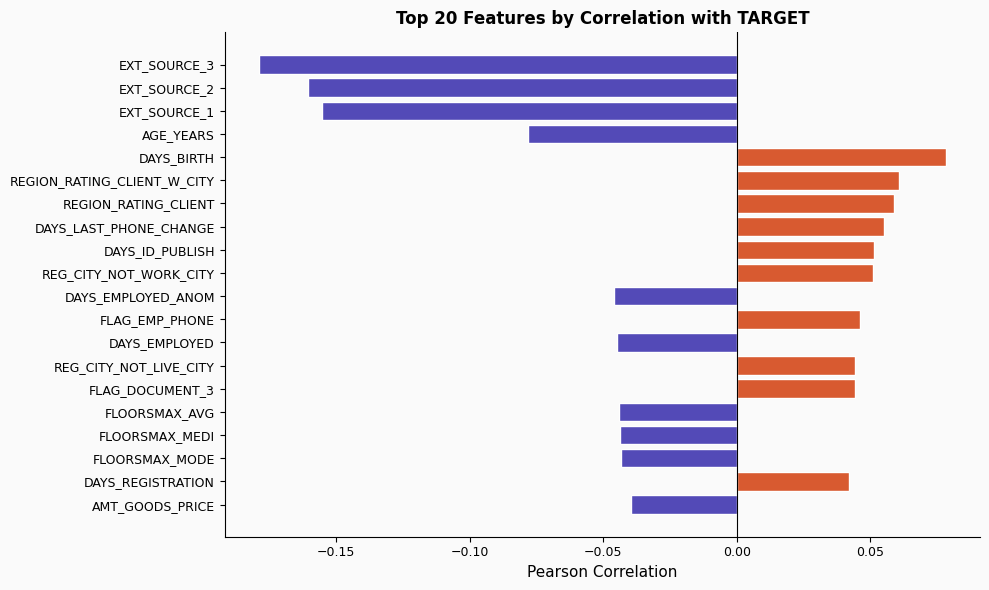

→ EXT_SOURCE features dominate. Negative correlation = higher score → lower default.


In [11]:
# ── Top correlations with TARGET ─────────────────────────────────────────────
numeric_train = train.select_dtypes(include='number').drop(
    columns=[c for c in ID_COLS if c in train.columns], errors='ignore'
)
target_corr = numeric_train.corr()['TARGET'].drop('TARGET').sort_values(key=abs, ascending=False)

print('Top 20 features by absolute correlation with TARGET:')
print(target_corr.head(20).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
top_corr = target_corr.head(20)
colors   = [C1 if v > 0 else C0 for v in top_corr.values]
ax.barh(top_corr.index, top_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Top 20 Features by Correlation with TARGET', fontsize=12, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('phase2_target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ EXT_SOURCE features dominate. Negative correlation = higher score → lower default.')

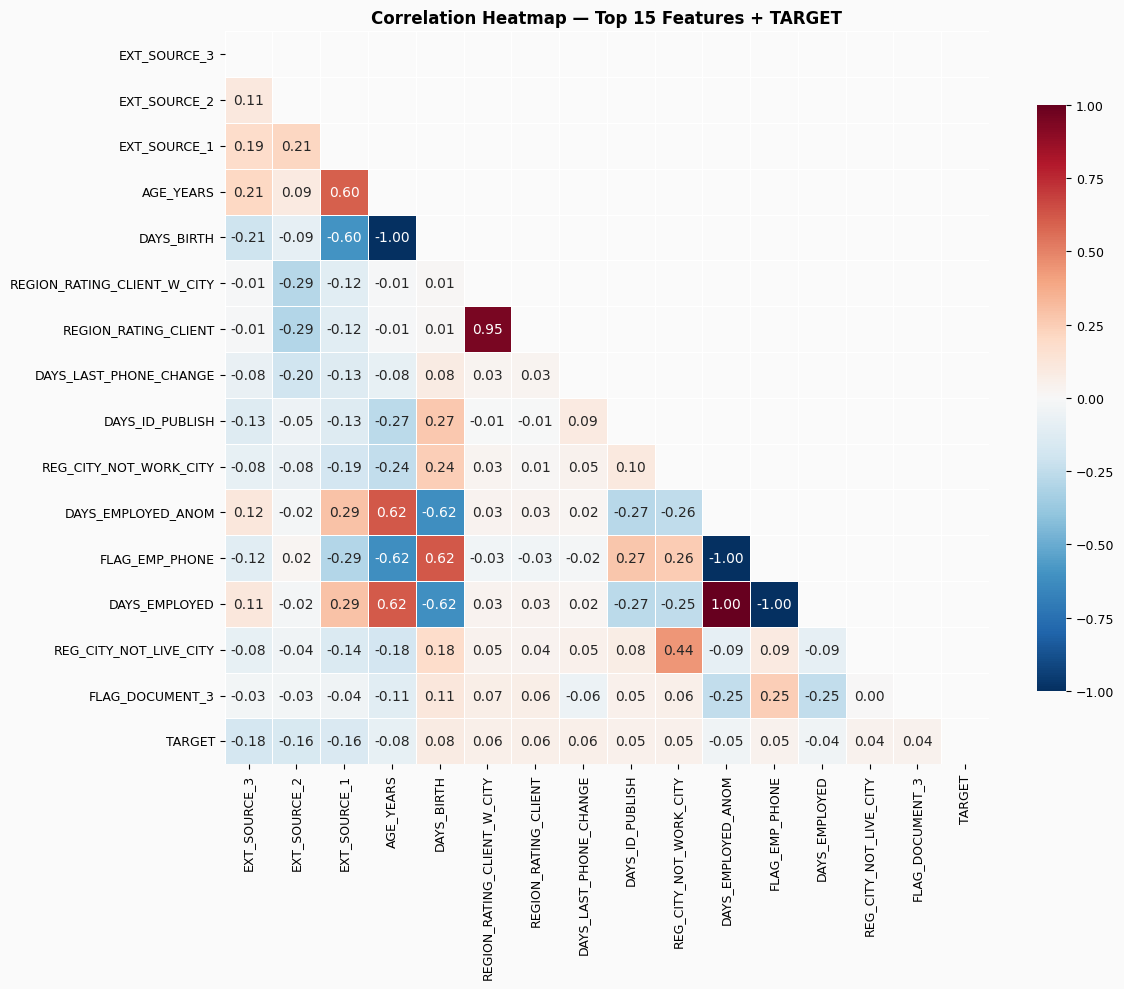

In [12]:
# ── Feature-feature correlation heatmap (top correlated features only) ─────────
top_features = target_corr.head(15).index.tolist() + ['TARGET']
top_features = [c for c in top_features if c in numeric_train.columns]

corr_matrix = numeric_train[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.8}, ax=ax
)
ax.set_title('Correlation Heatmap — Top 15 Features + TARGET', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('phase2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Outlier Detection

We use the IQR method and Z-score to flag extreme outlier columns.
Outliers in financial data are often real (rich clients, large loans) — we **cap rather than drop** them.

In [13]:
def outlier_summary(df, cols, method='iqr'):
    rows = []
    for col in cols:
        s = df[col].dropna()
        if method == 'iqr':
            Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
            IQR    = Q3 - Q1
            lower, upper = Q1 - 3*IQR, Q3 + 3*IQR
        else:  # z-score
            lower = s.mean() - 3 * s.std()
            upper = s.mean() + 3 * s.std()
        n_out = ((s < lower) | (s > upper)).sum()
        rows.append({'Column': col, 'Outlier count': n_out,
                     'Outlier %': round(n_out/len(s)*100, 2),
                     'Lower bound': round(lower, 2), 'Upper bound': round(upper, 2)})
    return pd.DataFrame(rows).sort_values('Outlier %', ascending=False)


financial_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
                  'AMT_GOODS_PRICE', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS']
financial_cols = [c for c in financial_cols if c in train.columns]

out_df = outlier_summary(train, financial_cols)
display(out_df)
print('\n→ Strategy: Cap at 99th percentile (not drop) — financial outliers carry signal.')
print('→ Exception: CNT_CHILDREN > 10 are clearly data errors — can cap at 5.')

,Column,Outlier count,Outlier %,Lower bound,Upper bound
0,AMT_INCOME_TOTAL,3014,0.9800,"-157,500.0000","472,500.0000"
3,AMT_GOODS_PRICE,1090,0.3500,"-1,084,500.0000","2,002,500.0000"
2,AMT_ANNUITY,1024,0.3300,"-37,692.0000","88,812.0000"
1,AMT_CREDIT,444,0.1400,"-1,345,950.0000","2,424,600.0000"
4,CNT_CHILDREN,126,0.0400,-3.0000,4.0000
5,CNT_FAM_MEMBERS,121,0.0400,-1.0000,6.0000



→ Strategy: Cap at 99th percentile (not drop) — financial outliers carry signal.
→ Exception: CNT_CHILDREN > 10 are clearly data errors — can cap at 5.


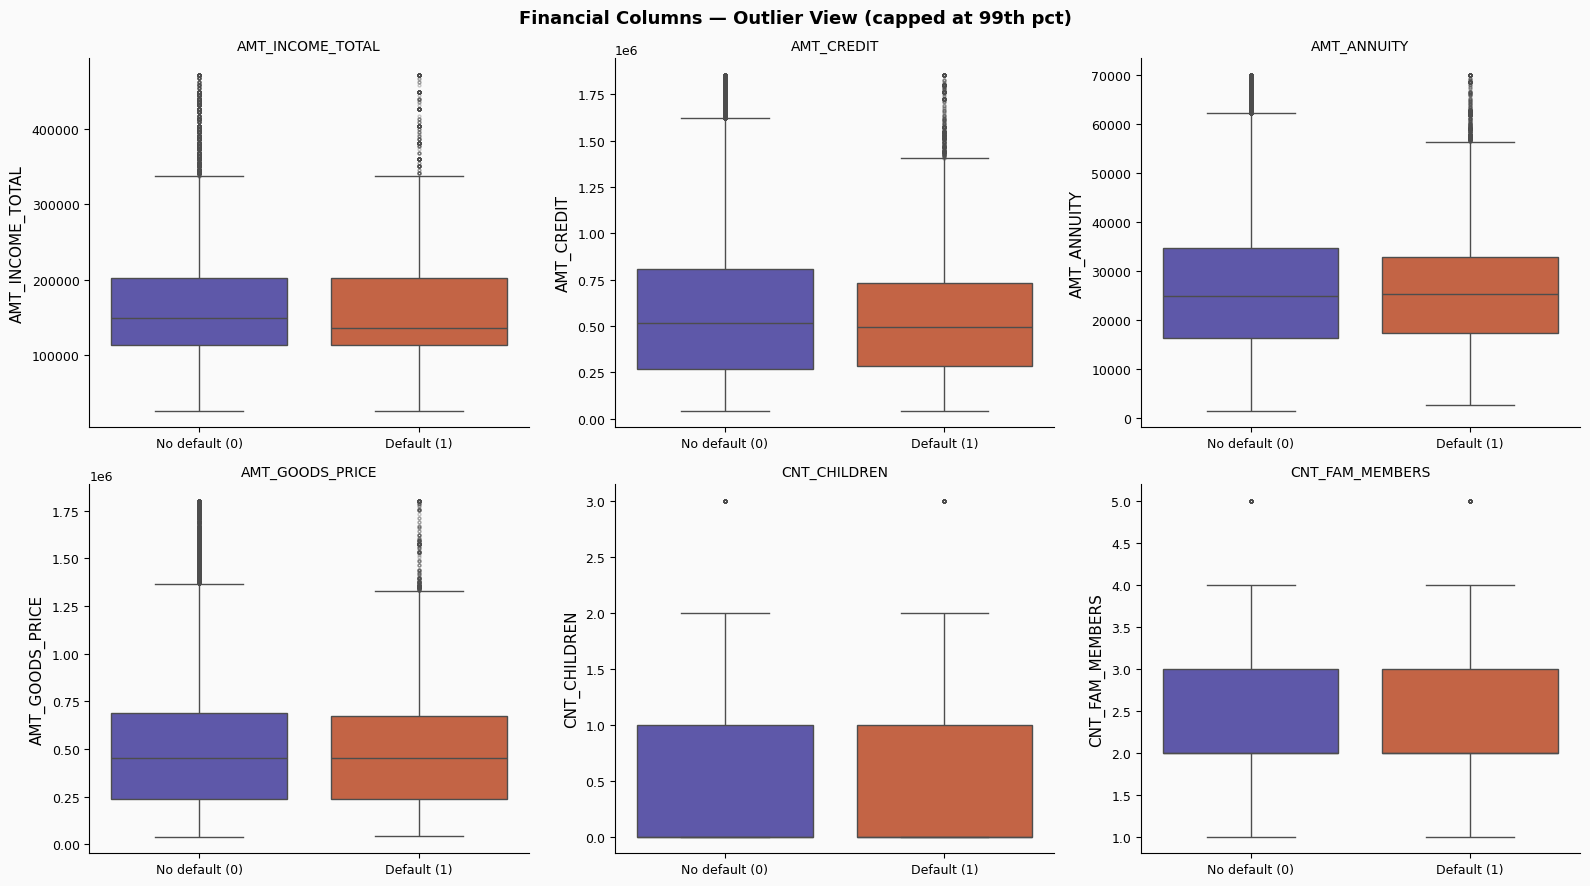

In [16]:
# ── Boxplots for financial columns split by TARGET ────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Financial Columns — Outlier View (capped at 99th pct)', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(financial_cols):
    ax = axes[i]
    q99 = train[col].quantile(0.99)
    plot_df = train[[col, 'TARGET']].copy()
    plot_df[col] = plot_df[col].clip(upper=q99)
    sns.boxplot(data=plot_df, x='TARGET', y=col,
                palette={'0': C0, '1': C1}, ax=ax,
                flierprops={'markersize': 2, 'alpha': 0.3})
    ax.set_xticklabels(['No default (0)', 'Default (1)'])
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')

for j in range(len(financial_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('phase2_outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## Secondary File EDA

Quick EDA on each secondary file to understand what features to aggregate in Phase 4.

In [17]:
# ── bureau.csv EDA ────────────────────────────────────────────────────────────
if 'bureau' in dfs:
    b = dfs['bureau']
    print('bureau.csv — Key stats')
    print(f'  Shape                  : {b.shape}')
    print(f'  Avg loans per applicant: {len(b)/b["SK_ID_CURR"].nunique():.1f}')
    print()

    print('  CREDIT_ACTIVE value counts:')
    print(b['CREDIT_ACTIVE'].value_counts().to_string())
    print()
    print('  CREDIT_TYPE value counts:')
    print(b['CREDIT_TYPE'].value_counts().to_string())
    print()

    # Null percentages
    null_b = b.isnull().mean().sort_values(ascending=False)
    null_b = null_b[null_b > 0]
    print('  Columns with nulls:')
    for col, pct in null_b.items():
        print(f'    {col:<40} {pct*100:.1f}%')

bureau.csv — Key stats
  Shape                  : (1716428, 17)
  Avg loans per applicant: 5.6

  CREDIT_ACTIVE value counts:
CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21

  CREDIT_TYPE value counts:
CREDIT_TYPE
Consumer credit                                 1251615
Credit card                                      402195
Car loan                                          27690
Mortgage                                          18391
Microloan                                         12413
Loan for business development                      1975
Another type of loan                               1017
Unknown type of loan                                555
Loan for working capital replenishment              469
Cash loan (non-earmarked)                            56
Real estate loan                                     27
Loan for the purchase of equipment                   19
Loan for purchase of shares (margin lending)          4
Mobile oper

In [18]:
# ── previous_application.csv EDA ─────────────────────────────────────────────
if 'previous_application' in dfs:
    pa = dfs['previous_application']
    print('previous_application.csv — Key stats')
    print(f'  Shape                           : {pa.shape}')
    print(f'  Avg prev applications per client: {len(pa)/pa["SK_ID_CURR"].nunique():.1f}')
    print()

    print('  NAME_CONTRACT_STATUS (most important col):')
    print(pa['NAME_CONTRACT_STATUS'].value_counts().to_string())
    print()
    print('  NAME_CONTRACT_TYPE:')
    print(pa['NAME_CONTRACT_TYPE'].value_counts().to_string())
    print()

    # DAYS_DECISION anomaly
    anom = (pa['AMT_ANNUITY'] == 365243).sum() if 'AMT_ANNUITY' in pa.columns else 0
    print(f'  AMT_ANNUITY==365243 anomalies: {anom}')
    print('  → Replace 365243 in numeric cols with NaN during Phase 3')

previous_application.csv — Key stats
  Shape                           : (1670214, 37)
  Avg prev applications per client: 4.9

  NAME_CONTRACT_STATUS (most important col):
NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436

  NAME_CONTRACT_TYPE:
NAME_CONTRACT_TYPE
Cash loans         747553
Consumer loans     729151
Revolving loans    193164
XNA                   346

  AMT_ANNUITY==365243 anomalies: 0
  → Replace 365243 in numeric cols with NaN during Phase 3


In [19]:
# ── installments_payments.csv EDA ─────────────────────────────────────────────
if 'installments_payments' in dfs:
    ip = dfs['installments_payments']
    print('installments_payments.csv — Key stats')
    print(f'  Shape: {ip.shape}')

    # Payment ratio: how much was actually paid vs what was due
    ip['PAYMENT_RATIO']  = ip['AMT_PAYMENT'] / (ip['AMT_INSTALMENT'] + 1e-5)
    ip['PAYMENT_DIFF']   = ip['AMT_INSTALMENT'] - ip['AMT_PAYMENT']   # positive = underpaid
    ip['DAYS_PAST_DUE']  = ip['DAYS_ENTRY_PAYMENT'] - ip['DAYS_INSTALMENT']
    ip['DAYS_PAST_DUE']  = ip['DAYS_PAST_DUE'].clip(lower=0)          # negative = early payment

    print(f'  Avg PAYMENT_RATIO: {ip["PAYMENT_RATIO"].median():.3f}')
    print(f'  % payments past due: {(ip["DAYS_PAST_DUE"] > 0).mean()*100:.2f}%')
    print()
    print('  → Will aggregate per SK_ID_CURR:')
    print('    mean/max/sum of PAYMENT_RATIO, PAYMENT_DIFF, DAYS_PAST_DUE in Phase 4')

installments_payments.csv — Key stats
  Shape: (13605401, 8)
  Avg PAYMENT_RATIO: 1.000
  % payments past due: 8.43%

  → Will aggregate per SK_ID_CURR:
    mean/max/sum of PAYMENT_RATIO, PAYMENT_DIFF, DAYS_PAST_DUE in Phase 4


In [20]:
# ── POS_CASH_balance.csv EDA ──────────────────────────────────────────────────
if 'POS_CASH_balance' in dfs:
    pos = dfs['POS_CASH_balance']
    print('POS_CASH_balance.csv — Key stats')
    print(f'  Shape: {pos.shape}')
    print('  NAME_CONTRACT_STATUS:')
    print(pos['NAME_CONTRACT_STATUS'].value_counts().to_string())
    print()
    print(f'  CNT_INSTALMENT_FUTURE — mean: {pos["CNT_INSTALMENT_FUTURE"].mean():.1f}, '
          f'null%: {pos["CNT_INSTALMENT_FUTURE"].isnull().mean()*100:.1f}%')
    print('  → Active contracts, remaining installments → aggregate per SK_ID_CURR')

POS_CASH_balance.csv — Key stats
  Shape: (10001358, 8)
  NAME_CONTRACT_STATUS:
NAME_CONTRACT_STATUS
Active                   9151119
Completed                 744883
Signed                     87260
Demand                      7065
Returned to the store       5461
Approved                    4917
Amortized debt               636
Canceled                      15
XNA                            2

  CNT_INSTALMENT_FUTURE — mean: 10.5, null%: 0.3%
  → Active contracts, remaining installments → aggregate per SK_ID_CURR


In [21]:
# ── credit_card_balance.csv EDA ───────────────────────────────────────────────
if 'credit_card_balance' in dfs:
    cc = dfs['credit_card_balance']
    print('credit_card_balance.csv — Key stats')
    print(f'  Shape: {cc.shape}')
    print(f'  Unique SK_ID_CURR: {cc["SK_ID_CURR"].nunique():,}')

    if 'AMT_BALANCE' in cc.columns and 'AMT_CREDIT_LIMIT_ACTUAL' in cc.columns:
        cc['UTILIZATION_RATIO'] = cc['AMT_BALANCE'] / (cc['AMT_CREDIT_LIMIT_ACTUAL'] + 1e-5)
        print(f'  Credit utilization — median: {cc["UTILIZATION_RATIO"].median():.3f}')
    print('  → Key features: utilization ratio, drawings, payments — aggregate in Phase 4')

credit_card_balance.csv — Key stats
  Shape: (3840312, 23)
  Unique SK_ID_CURR: 103,558
  Credit utilization — median: 0.000
  → Key features: utilization ratio, drawings, payments — aggregate in Phase 4


In [22]:
print('=' * 65)
print('  PHASE 2 EDA SUMMARY')
print('=' * 65)

print()
print('KEY FINDINGS:')
print('  1. EXT_SOURCE_1/2/3 — strongest predictors, negative correlation with default.')
print('     → Will create: EXT_SOURCE_mean, EXT_SOURCE_min, EXT_SOURCE_product')
print()
print('  2. DAYS_EMPLOYED has 365243 anomaly (unemployed) → replace with NaN + create flag.')
print('     The anomaly flag itself has predictive signal.')
print()
print('  3. Younger clients (20-30) default more. DAYS_BIRTH → AGE_YEARS feature.')
print()
print('  4. AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY are heavily right-skewed.')
print('     → Apply log1p transformation in Phase 3.')
print()
print('  5. Class imbalance: ~8.07% default rate → use scale_pos_weight or class_weight.')
print()
print('  6. installments_payments: PAYMENT_RATIO and DAYS_PAST_DUE are strong signals.')
print()
print('  7. credit_card_balance: utilization ratio is an important feature to engineer.')
print()
print('FEATURES TO CREATE IN PHASE 4:')
features_to_create = [
    'CREDIT_INCOME_RATIO       = AMT_CREDIT / AMT_INCOME_TOTAL',
    'ANNUITY_INCOME_RATIO      = AMT_ANNUITY / AMT_INCOME_TOTAL',
    'CREDIT_TERM               = AMT_CREDIT / AMT_ANNUITY',
    'DAYS_EMPLOYED_PERCENT     = DAYS_EMPLOYED / DAYS_BIRTH',
    'AGE_YEARS                 = -DAYS_BIRTH / 365',
    'INCOME_PER_PERSON         = AMT_INCOME_TOTAL / CNT_FAM_MEMBERS',
    'EXT_SOURCE_MEAN           = mean(EXT_SOURCE_1, 2, 3)',
    'EXT_SOURCE_MIN            = min(EXT_SOURCE_1, 2, 3)',
    'EXT_SOURCE_PRODUCT        = EXT_SOURCE_1 * EXT_SOURCE_2 * EXT_SOURCE_3',
    'DAYS_EMPLOYED_ANOM        = 1 if DAYS_EMPLOYED == 365243',
    'bureau_*                  = agg stats from bureau.csv',
    'prev_app_*                = agg stats from previous_application.csv',
    'installments_*            = agg stats (payment ratio, days past due)',
    'pos_cash_*                = agg stats (remaining installments, active count)',
    'cc_*                      = agg stats (utilization, drawings, payments)',
]
for f in features_to_create:
    print(f'  • {f}')

print()
print('→ Phase 3 next: Preprocessing (imputation, encoding, scaling, outlier capping)')

  PHASE 2 EDA SUMMARY

KEY FINDINGS:
  1. EXT_SOURCE_1/2/3 — strongest predictors, negative correlation with default.
     → Will create: EXT_SOURCE_mean, EXT_SOURCE_min, EXT_SOURCE_product

  2. DAYS_EMPLOYED has 365243 anomaly (unemployed) → replace with NaN + create flag.
     The anomaly flag itself has predictive signal.

  3. Younger clients (20-30) default more. DAYS_BIRTH → AGE_YEARS feature.

  4. AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY are heavily right-skewed.
     → Apply log1p transformation in Phase 3.

  5. Class imbalance: ~8.07% default rate → use scale_pos_weight or class_weight.

  6. installments_payments: PAYMENT_RATIO and DAYS_PAST_DUE are strong signals.

  7. credit_card_balance: utilization ratio is an important feature to engineer.

FEATURES TO CREATE IN PHASE 4:
  • CREDIT_INCOME_RATIO       = AMT_CREDIT / AMT_INCOME_TOTAL
  • ANNUITY_INCOME_RATIO      = AMT_ANNUITY / AMT_INCOME_TOTAL
  • CREDIT_TERM               = AMT_CREDIT / AMT_ANNUITY
  • DAYS_EMPLOYE